In [44]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import datetime
import matplotlib.dates as mdates
from matplotlib import rcParams
import matplotlib as mpl
plt.rc('text', usetex=True)
plt.rc('text.latex',unicode=True)
plt.rc('text.latex',preamble='\\usepackage[utf8]{inputenc}')
plt.rc('text.latex',preamble='\\usepackage[russian]{babel}')
plt.style.use('fivethirtyeight')
rcParams['font.family'] = 'monospace'
rcParams['font.size'] = 20

/Users/hayk/anaconda3/envs/sci/lib/python3.7/site-packages/ipykernel_launcher.py:9: MatplotlibDeprecationWarning: 
The text.latex.unicode rcparam was deprecated in Matplotlib 3.0 and will be removed in 3.2.
  if __name__ == '__main__':


In [178]:
def predict(time, y0, R0, Tinf = 3):
    def SIR(funcs, t, R0, Tinf):
        S, I, R = funcs
        beta = R0 / Tinf
        gamma = 1.0 / Tinf
        return [
            -beta * I * S / (S + I + R),
            beta * I * S / (S + I + R) - I * gamma,
            I * gamma
        ]
    sol = odeint(func=SIR, y0=y0, t=time, args=(R0, Tinf), hmax=0.01)
    return (np.array(time), np.array(sol))


In [179]:
R0 = 2.5
Tinf = 3
beta = R0 / Tinf
gamma = 1 / Tinf
N0 = 150e6
I0 = 1

interval = np.arange(100)
sol = predict(interval, [N0, 1, 0], R0=R0, Tinf=Tinf)

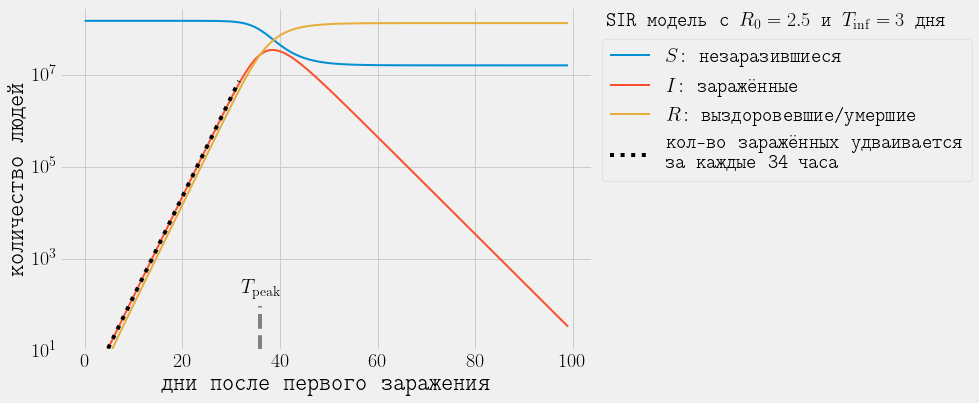

In [182]:
fig = plt.figure(figsize=(14, 6))
ax = plt.subplot(111)
ax.plot(sol[0], sol[1][:,0], label=r'$S$: незаразившиеся', lw=2);
ax.plot(sol[0], sol[1][:,1], label=r'$I$: заражённые', lw=2);
ax.plot(sol[0], sol[1][:,2], label=r'$R$: выздоровевшие/умершие', lw=2);
ax.set_xlabel(r'дни после первого заражения')
ax.set_ylabel(r'количество людей')

xs = np.logspace(0, 1.5, 20)
ys = I0 * np.exp((R0-1.0) * xs/Tinf)
ax.plot(xs, ys, c='k', ls=':', label='кол-во заражённых удваивается\nза каждые 34 часа')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.7))
ax.text(107, 8e7, r'SIR модель с $R_0=2.5$ и $T_{\rm inf}=3$ дня', ha='left', va='bottom')

ax.axvline(36, c='gray', lw=4, ls='--', ymax=0.13)
ax.text(36, 200, r'$T_{\rm peak}$', ha='center', va='center')
ax.set_ylim(1e1, N0 * 2)
ax.set_yscale('log');
plt.tight_layout()
plt.savefig('sir.png', dpi=300)

In [186]:
sol[1][:,1].max()/1e6

34.76346175681042

In [191]:
def predict(time, y0, R0, Tinf = 3, Tinc = 5):
    def SEIR(funcs, t, R0, Tinf, Tinc):
        S, E, I, R = funcs
        beta = R0 / Tinf
        sigma = 1.0 / Tinc
        gamma = 1.0 / Tinf
        return [
            -beta * I * S / (S + E + I + R),
            beta * I * S / (S + E + I + R) - E * sigma,
            E * sigma - gamma * I,
            I * gamma
        ]
    sol = odeint(func=SEIR, y0=y0, t=time, args=(R0, Tinf, Tinc), hmax=0.01)
    return (np.array(time), np.array(sol))


In [192]:
R0 = 2.5
Tinf = 3
Tinc = 5
# beta = R0 / Tinf
# gamma = 1 / Tinf
N0 = 150e6
I0 = 1

interval = np.arange(260)
sol = predict(interval, [N0, 0, I0, 0], R0=R0, Tinf=Tinf, Tinc=Tinc)

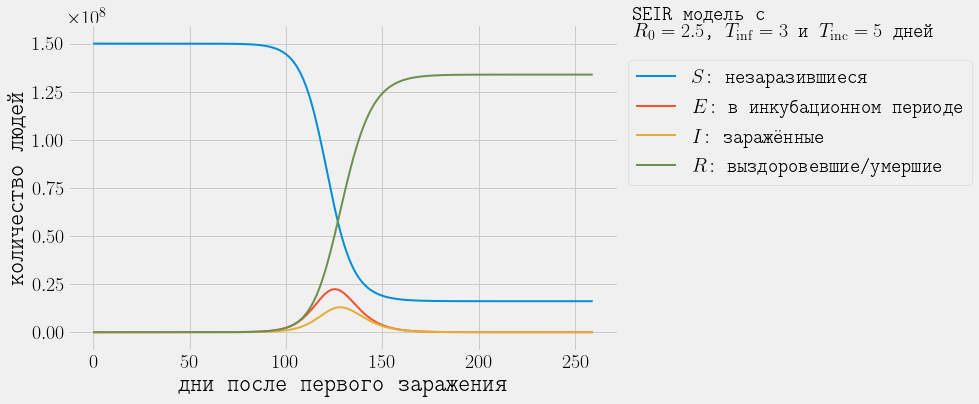

In [193]:
fig = plt.figure(figsize=(14, 6))
ax = plt.subplot(111)
ax.plot(sol[0], sol[1][:,0], label=r'$S$: незаразившиеся', lw=2);
ax.plot(sol[0], sol[1][:,1], label=r'$E$: в инкубационном периоде', lw=2);
ax.plot(sol[0], sol[1][:,2], label=r'$I$: заражённые', lw=2);
ax.plot(sol[0], sol[1][:,3], label=r'$R$: выздоровевшие/умершие', lw=2);
ax.set_xlabel(r'дни после первого заражения')
ax.set_ylabel(r'количество людей')

plt.legend(loc='center left', bbox_to_anchor=(1, 0.7))
ax.text(280, 1.5e8, 'SEIR модель с\n$R_0=2.5$, $T_{\\rm inf}=3$ и $T_{\\rm inc}=5$ дней', ha='left', va='bottom')

ax.set_ylim(-1e7, N0 + 1e7);
plt.tight_layout()
# plt.savefig('seir.png', dpi=300)

In [207]:
sol[1][:,3].max()/N0

0.8926445649130178

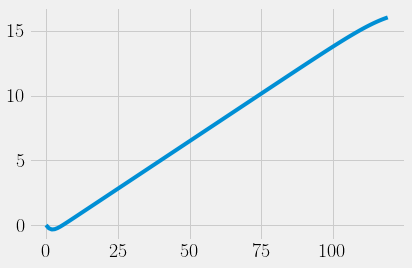

In [198]:
plt.plot(sol[0][sol[0] < 120], np.log(sol[1][:,2][sol[0] < 120]))

In [204]:
np.exp(5 / 7.5)

1.9477340410546757